In [1]:
install.packages("tidyverse")
install.packages("skimr")
install.packages("naniar")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’




In [2]:
library(tidyverse)
library(skimr)
library(naniar)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘naniar’


The following object is masked from ‘package:skimr’:

    n_complete




In [4]:
#=========================================================
# Task 1: Import and Inspect the Dataset
#=========================================================

# Read the CSV file using tryCatch() for error handling
air_data <- tryCatch(

  {
    # Read the dataset (make sure the file is uploaded in Colab's Files section)
    read.csv("PRSA_Data_Aotizhongxin_20130301-20170228.csv")
  },

  warning = function(w) {
    cat("Warning:", conditionMessage(w), "\n")
    return(NULL)
  },

  error = function(e) {

    # Display meaningful error messages
    if (grepl("cannot open", e$message)) {
      cat("Error: File not found or cannot be opened.\n")
    } else if (grepl("no lines available|invalid", e$message)) {
      cat("Error: Incorrect or invalid CSV file format.\n")
    } else {
      cat("Error:", e$message, "\n")
    }

    return(NULL)
  }

)

# Proceed only if the dataset is loaded successfully
if (!is.null(air_data)) {

  cat("==============================\n")
  cat("Dataset Loaded Successfully\n")
  cat("==============================\n\n")

  #-------------------------------------------------------
  # 1. Display the first six records
  #-------------------------------------------------------
  cat("1. First Six Records\n")
  print(head(air_data))

  #-------------------------------------------------------
  # 2. Display the structure of the dataset
  #-------------------------------------------------------
  cat("\n\n2. Dataset Structure\n")
  str(air_data)

  #-------------------------------------------------------
  # 3. Display number of rows and columns
  #-------------------------------------------------------
  cat("\n\n3. Dataset Dimensions\n")
  cat("Number of Rows    :", nrow(air_data), "\n")
  cat("Number of Columns :", ncol(air_data), "\n")

  #-------------------------------------------------------
  # 4. Check whether dataset contains missing values
  #-------------------------------------------------------
  cat("\n4. Does the dataset contain missing values?\n")

  if (any(is.na(air_data))) {
    cat("Yes, the dataset contains missing values.\n")
  } else {
    cat("No, the dataset does not contain missing values.\n")
  }

  #-------------------------------------------------------
  # 5. Display total number of missing values
  #-------------------------------------------------------
  cat("\n5. Total Missing Values in Dataset :", sum(is.na(air_data)), "\n")

}

Dataset Loaded Successfully

1. First Six Records
  No year month day hour PM2.5 PM10 SO2 NO2  CO O3 TEMP   PRES  DEWP RAIN  wd
1  1 2013     3   1    0     4    4   4   7 300 77 -0.7 1023.0 -18.8    0 NNW
2  2 2013     3   1    1     8    8   4   7 300 77 -1.1 1023.2 -18.2    0   N
3  3 2013     3   1    2     7    7   5  10 300 73 -1.1 1023.5 -18.2    0 NNW
4  4 2013     3   1    3     6    6  11  11 300 72 -1.4 1024.5 -19.4    0  NW
5  5 2013     3   1    4     3    3  12  12 300 72 -2.0 1025.2 -19.5    0   N
6  6 2013     3   1    5     5    5  18  18 400 66 -2.2 1025.6 -19.6    0   N
  WSPM      station
1  4.4 Aotizhongxin
2  4.7 Aotizhongxin
3  5.6 Aotizhongxin
4  3.1 Aotizhongxin
5  2.0 Aotizhongxin
6  3.7 Aotizhongxin


2. Dataset Structure
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ 

In [5]:
#=========================================================
# Task 2: Understand NA, NULL, and NaN
#=========================================================

#-----------------------------
# Example of NA (Missing Value)
#-----------------------------
# NA represents a missing or unavailable value.

temperature <- c(28, 30, NA, 32)

cat("Temperature Vector:\n")
print(temperature)

# Check for NA values
cat("\nChecking NA values using is.na():\n")
print(is.na(temperature))


#-----------------------------
# Example of NULL (Empty Object)
#-----------------------------
# NULL represents an object with no value.

missing_object <- NULL

cat("\nValue of missing_object:\n")
print(missing_object)

# Check if the object is NULL
cat("\nChecking NULL using is.null():\n")
print(is.null(missing_object))


#-----------------------------
# Example of NaN (Not a Number)
#-----------------------------
# NaN is produced by an undefined mathematical operation.

undefined_value <- 0 / 0

cat("\nValue of undefined_value:\n")
print(undefined_value)

# Check if the value is NaN
cat("\nChecking NaN using is.nan():\n")
print(is.nan(undefined_value))


#----------------------------------------------------
# Additional Examples (Optional)
#----------------------------------------------------

# Another NA example
marks <- c(85, 90, NA, 78)

# Another NULL example
student_name <- NULL

# Another NaN example
result <- sqrt(-1)

cat("\nAdditional Examples\n")

cat("\nMarks:\n")
print(marks)

cat("\nStudent Name:\n")
print(student_name)

cat("\nSquare Root of -1:\n")
print(result)


#----------------------------------------------------
# Summary Table
#----------------------------------------------------

summary_table <- data.frame(

  Value = c("NA", "NULL", "NaN"),

  Meaning = c(
    "Missing or unavailable value",
    "Empty or absent object",
    "Undefined mathematical result"
  ),

  Identification_Function = c(
    "is.na()",
    "is.null()",
    "is.nan()"
  )

)

cat("\nSummary Table:\n")
print(summary_table)

Temperature Vector:
[1] 28 30 NA 32

Checking NA values using is.na():
[1] FALSE FALSE  TRUE FALSE

Value of missing_object:
NULL

Checking NULL using is.null():
[1] TRUE

Value of undefined_value:
[1] NaN

Checking NaN using is.nan():
[1] TRUE


Warning message in sqrt(-1):
“NaNs produced”



Additional Examples

Marks:
[1] 85 90 NA 78

Student Name:
NULL

Square Root of -1:
[1] NaN

Summary Table:
  Value                       Meaning Identification_Function
1    NA  Missing or unavailable value                 is.na()
2  NULL        Empty or absent object               is.null()
3   NaN Undefined mathematical result                is.nan()


In [6]:
#=========================================================
# Task 3: Create a Missing-Value Summary Function
#=========================================================

# Create a user-defined function to summarize missing values
missing_summary <- function(data) {

  # List of variables to analyze
  selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

  # Create an empty data frame to store results
  summary_table <- data.frame(
    Variable = character(),
    Total_Records = integer(),
    Missing_Values = integer(),
    Missing_Percentage = numeric(),
    stringsAsFactors = FALSE
  )

  # Loop through each selected variable
  for (var in selected_variables) {

    # Check if the variable exists in the dataset
    if (var %in% names(data)) {

      # Total number of records
      total_records <- nrow(data)

      # Count missing values
      missing_values <- sum(is.na(data[[var]]))

      # Calculate missing percentage
      missing_percentage <- (missing_values / total_records) * 100

      # Add results to the summary table
      summary_table <- rbind(
        summary_table,
        data.frame(
          Variable = var,
          Total_Records = total_records,
          Missing_Values = missing_values,
          Missing_Percentage = round(missing_percentage, 2)
        )
      )

      # Generate a warning if missing percentage exceeds 20%
      if (missing_percentage > 20) {
        warning(
          paste(
            "Warning:",
            var,
            "contains more than 20% missing values."
          )
        )
      }

    } else {

      # Display message if the variable does not exist
      cat("Variable", var, "does not exist in the dataset.\n")

    }
  }

  # Return the summary table
  return(summary_table)
}

#---------------------------------------------------------
# Apply the function to the dataset
#---------------------------------------------------------

missing_value_summary <- missing_summary(air_data)

# Display the summary table
cat("Missing Value Summary:\n")
print(missing_value_summary)

Missing Value Summary:
  Variable Total_Records Missing_Values Missing_Percentage
1    PM2.5         35064            925               2.64
2     PM10         35064            718               2.05
3      SO2         35064            935               2.67
4      NO2         35064           1023               2.92
5     TEMP         35064             20               0.06
6     WSPM         35064             14               0.04
7       wd         35064             81               0.23


In [7]:
#=========================================================
# Task 4: Identify Invalid Numerical Results
#=========================================================

# Create a new variable 'pollution_ratio'
# It is calculated by dividing PM2.5 by PM10

air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

#---------------------------------------------------------
# Check for invalid values
#---------------------------------------------------------

# Count NA values
na_count <- sum(is.na(air_data$pollution_ratio))

# Count NaN values
nan_count <- sum(is.nan(air_data$pollution_ratio))

# Count Infinite values (both +Inf and -Inf)
infinite_count <- sum(is.infinite(air_data$pollution_ratio))

# Count Positive Infinity
positive_inf <- sum(air_data$pollution_ratio == Inf, na.rm = TRUE)

# Count Negative Infinity
negative_inf <- sum(air_data$pollution_ratio == -Inf, na.rm = TRUE)

# Display the results
cat("Summary of Invalid Values in pollution_ratio\n")
cat("-------------------------------------------\n")
cat("NA Values                :", na_count, "\n")
cat("NaN Values               :", nan_count, "\n")
cat("Positive Infinity Values :", positive_inf, "\n")
cat("Negative Infinity Values :", negative_inf, "\n")
cat("Total Infinite Values    :", infinite_count, "\n")

#---------------------------------------------------------
# Replace NaN and Infinite values with NA
#---------------------------------------------------------

air_data$pollution_ratio[
  is.nan(air_data$pollution_ratio) |
  is.infinite(air_data$pollution_ratio)
] <- NA

#---------------------------------------------------------
# Verify after replacement
#---------------------------------------------------------

cat("\nAfter Replacing Invalid Values\n")
cat("-------------------------------------------\n")
cat("NA Values             :", sum(is.na(air_data$pollution_ratio)), "\n")
cat("NaN Values            :", sum(is.nan(air_data$pollution_ratio)), "\n")
cat("Infinite Values       :", sum(is.infinite(air_data$pollution_ratio)), "\n")

# Display first few values of the new variable
cat("\nFirst 10 Pollution Ratio Values:\n")
print(head(air_data$pollution_ratio, 10))

Summary of Invalid Values in pollution_ratio
-------------------------------------------
NA Values                : 934 
NaN Values               : 0 
Positive Infinity Values : 0 
Negative Infinity Values : 0 
Total Infinite Values    : 0 

After Replacing Invalid Values
-------------------------------------------
NA Values             : 934 
NaN Values            : 0 
Infinite Values       : 0 

First 10 Pollution Ratio Values:
 [1] 1.000 1.000 1.000 1.000 1.000 1.000 1.000 0.500 0.500 0.375


In [8]:
#=========================================================
# Task 5: Handle Missing Numerical Values Using a Loop
#=========================================================

# Vector containing numerical variables
numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

# Loop through each variable
for (var in numeric_variables) {

  # Check if the column exists in the dataset
  if (var %in% names(air_data)) {

    # Count missing values before treatment
    missing_before <- sum(is.na(air_data[[var]]))

    # Calculate median (ignoring missing values)
    median_value <- median(air_data[[var]], na.rm = TRUE)

    # Replace missing values with the median
    air_data[[var]][is.na(air_data[[var]])] <- median_value

    # Count missing values after treatment
    missing_after <- sum(is.na(air_data[[var]]))

    # Display results
    cat("=========================================\n")
    cat("Variable Name               :", var, "\n")
    cat("Missing Values Before       :", missing_before, "\n")
    cat("Median Used for Replacement :", median_value, "\n")
    cat("Missing Values After        :", missing_after, "\n")
    cat("=========================================\n\n")

  } else {

    # Display message if column does not exist
    cat("Column", var, "does not exist in the dataset.\n\n")

  }

}

Variable Name               : PM2.5 
Missing Values Before       : 925 
Median Used for Replacement : 58 
Missing Values After        : 0 

Variable Name               : PM10 
Missing Values Before       : 718 
Median Used for Replacement : 87 
Missing Values After        : 0 

Variable Name               : SO2 
Missing Values Before       : 935 
Median Used for Replacement : 9 
Missing Values After        : 0 

Variable Name               : NO2 
Missing Values Before       : 1023 
Median Used for Replacement : 53 
Missing Values After        : 0 

Variable Name               : TEMP 
Missing Values Before       : 20 
Median Used for Replacement : 14.5 
Missing Values After        : 0 

Variable Name               : WSPM 
Missing Values Before       : 14 
Median Used for Replacement : 1.4 
Missing Values After        : 0 



In [9]:
#=========================================================
# Task 6: Handle Missing Categorical Values
#=========================================================

# Function to calculate the mode of a categorical variable
calculate_mode <- function(x) {

  # Remove missing values
  x <- x[!is.na(x)]

  # Find unique values
  unique_values <- unique(x)

  # Return the most frequent value (mode)
  mode_value <- unique_values[which.max(tabulate(match(x, unique_values)))]

  return(mode_value)
}

#---------------------------------------------------------
# Calculate mode of wd
#---------------------------------------------------------

mode_wd <- calculate_mode(air_data$wd)

# Count missing values before replacement
missing_before <- sum(is.na(air_data$wd))

# Replace missing values with mode
air_data$wd[is.na(air_data$wd)] <- mode_wd

# Count missing values after replacement
missing_after <- sum(is.na(air_data$wd))

#---------------------------------------------------------
# Display Results
#---------------------------------------------------------

cat("=========================================\n")
cat("Categorical Variable : wd\n")
cat("Mode Value           :", mode_wd, "\n")
cat("Missing Before       :", missing_before, "\n")
cat("Missing After        :", missing_after, "\n")
cat("=========================================\n")

Categorical Variable : wd
Mode Value           : NE 
Missing Before       : 81 
Missing After        : 0 


In [10]:
#=========================================================
# Task 7: Implement Error Handling
#=========================================================

# Reusable function to clean a numerical variable
clean_variable <- function(data, variable_name) {

  tryCatch({

    # Check if variable exists
    if (!(variable_name %in% names(data))) {
      stop("Variable does not exist in the dataset.")
    }

    # Check whether variable is numeric
    if (!is.numeric(data[[variable_name]])) {
      stop("The selected variable is not numerical.")
    }

    # Check if all values are missing
    if (all(is.na(data[[variable_name]]))) {
      stop("The variable contains only missing values.")
    }

    # Calculate median
    median_value <- median(data[[variable_name]], na.rm = TRUE)

    # Check if median can be calculated
    if (is.na(median_value)) {
      stop("Median cannot be calculated.")
    }

    # Replace missing values with median
    data[[variable_name]][is.na(data[[variable_name]])] <- median_value

    cat("Variable:", variable_name, "cleaned successfully.\n")
    cat("Median used:", median_value, "\n\n")

    return(data[[variable_name]])

  },

  error = function(e) {

    cat("Error:", e$message, "\n")

  })

}

#---------------------------------------------------------
# Example Function Calls
#---------------------------------------------------------

clean_variable(air_data, "PM2.5")

clean_variable(air_data, "wd")          # Non-numeric variable

clean_variable(air_data, "ABC")         # Variable does not exist

Variable: PM2.5 cleaned successfully.
Median used: 58 



[1]   4.0   8.0   7.0   6.0   3.0   5.0   3.0   3.0   3.0   3.0   3.0   3.0
   [13]   3.0   3.0   6.0   8.0   9.0  10.0  11.0   8.0  11.0  12.0  15.0  24.0
   [25]  22.0  14.0  13.0   3.0   3.0   9.0   4.0   3.0   3.0  10.0  11.0  18.0
   [37]  26.0  25.0  26.0  37.0  37.0  44.0  54.0  61.0  67.0  74.0  81.0  93.0
   [49] 112.0 109.0 110.0 105.0 106.0 101.0  91.0  79.0  77.0  83.0  94.0  96.0
   [61]  91.0  98.0  72.0  48.0  28.0  26.0  24.0  19.0  60.0 117.0  54.0  46.0
   [73]  42.0  49.0  34.0  12.0   7.0  10.0  13.0  14.0  13.0  15.0  16.0  18.0
   [85]  13.0   3.0   3.0  10.0  14.0  20.0  25.0  31.0  34.0  40.0  51.0  58.0
   [97]  71.0  91.0 100.0 103.0 115.0 117.0 104.0 106.0 111.0 114.0 131.0 138.0
  [109] 142.0 163.0 168.0 165.0 166.0 190.0 203.0 210.0 205.0 215.0 219.0 226.0
  [121] 284.0 272.0 242.0 212.0 192.0 188.0 186.0 188.0 194.0 184.0 175.0 179.0
  [133] 192.0 201.0 230.0 246.0 248.0 230.0 239.0 242.0 254.0 266.0 254.0 260.0
  [145] 250.0 240.0 238.0 243.0 246.0 275.0 306.0 320.0 292.0 251.0 228.0 217.0
  [157] 255.0 258.0 277.0 282.0 267.0 216.0 201.0 211.0 227.0 282.0 363.0 376.0
  [169] 344.0 339.0 339.0 324.0 322.0 315.0 310.0 309.0 310.0 326.0 326.0 219.0
  [181] 104.0 121.0 184.0 330.0 172.0 114.0  82.0  84.0  91.0  81.0  90.0  79.0
  [193]  49.0  89.0  89.0  98.0  97.0 102.0 110.0 108.0 104.0 113.0 145.0  69.0
  [205]  78.0  49.0  47.0  28.0  21.0  14.0  17.0  15.0  18.0  12.0  11.0   6.0
  [217]  11.0  11.0   6.0  10.0  18.0  21.0  18.0  24.0  31.0  26.0  27.0  30.0
  [229]  28.0  34.0  28.0  37.0  36.0  38.0  44.0  60.0  70.0  64.0  70.0  81.0
  [241]  90.0  95.0  95.0  96.0  97.0 106.0 114.0 112.0 113.0 120.0 141.0 140.0
  [253] 149.0 150.0 114.0 106.0 113.0 132.0 149.0 144.0 156.0 174.0 152.0 113.0
  [265]  89.0 106.0 125.0 117.0 112.0 140.0 146.0 115.0 120.0 116.0 123.0 130.0
  [277] 132.0 129.0 139.0 135.0 133.0 141.0 124.0 137.0 160.0 140.0  88.0  50.0
  [289]  22.0  10.0  10.0   7.0  11.0   3.0   3.0   3.0   8.0  20.0  16.0  14.0
  [301]  12.0  17.0  15.0   3.0   3.0   3.0  23.0  31.0  37.0  35.0  37.0  42.0
  [313]  62.0  71.0  60.0  65.0  49.0  72.0  73.0  69.0  72.0  84.0 101.0 111.0
  [325]  97.0 104.0 108.0 105.0 105.0 106.0 115.0 119.0 115.0 119.0 140.0 162.0
  [337] 165.0 180.0 183.0 182.0 173.0 166.0 163.0 137.0 164.0 172.0 173.0   3.0
  [349] 110.0 227.0 236.0 256.0 287.0 278.0 269.0 286.0 304.0 312.0 316.0 353.0
  [361] 355.0 328.0 308.0 304.0 314.0 276.0 276.0 275.0 278.0 272.0 264.0 270.0
  [373] 227.0 183.0 166.0 150.0 165.0 185.0 216.0 188.0 197.0 228.0 242.0 210.0
  [385] 166.0 162.0 176.0 217.0 183.0 180.0 184.0 206.0 206.0 257.0 267.0 293.0
  [397] 322.0 294.0 332.0 352.0 362.0 356.0 344.0 357.0 364.0 392.0 423.0 434.0
  [409] 450.0 463.0 308.0  36.0  30.0  20.0  14.0  13.0   3.0   3.0  13.0   6.0
  [421]   8.0  12.0  12.0  14.0  15.0   3.0  28.0  78.0  55.0  38.0  37.0  37.0
  [433]  31.0  30.0  31.0  33.0  31.0  29.0  32.0  30.0  34.0  38.0  51.0  59.0
  [445]  60.0  45.0  50.0  52.0  45.0  38.0  28.0  30.0  38.0  39.0  65.0  65.0
  [457]  68.0  47.0  40.0  52.0  52.0  31.0  23.0  27.0  39.0  42.0  24.0  40.0
  [469]  27.0  33.0  51.0  30.0  37.0  41.0  59.0  78.0  69.0  77.0  81.0 106.0
  [481]  92.0 112.0  97.0 103.0  78.0  73.0  73.0 112.0 116.0 120.0 130.0 142.0
  [493] 162.0 178.0 181.0 187.0 188.0 187.0 190.0 202.0 202.0 205.0 217.0 228.0
  [505] 202.0 172.0 160.0 117.0 160.0  65.0  18.0  26.0  10.0 146.0 142.0 137.0
  [517]  63.0  56.0  75.0  83.0  66.0  78.0  76.0  68.0  66.0  64.0  59.0  61.0
  [529]  64.0  60.0  51.0  51.0  44.0  44.0  51.0  53.0  62.0  78.0  79.0  80.0
  [541]  81.0  77.0  84.0  89.0  86.0  63.0  18.0  14.0  14.0  11.0   7.0   5.0
  [553]   6.0   8.0  10.0  11.0  13.0  13.0  18.0  11.0  14.0  14.0   3.0  11.0
  [565]  10.0   3.0   4.0   3.0   9.0  14.0  23.0  32.0  43.0  56.0  61.0  55.0
  [577]  56.0  66.0  73.0  79.0  80.0  71.0  71.0  77.0 108.0 120.0 121.0 110.0
  [589] 111.0 119.0 124.0 133.0 118.0 109.0 113.0 123.0 146.0 117.0 109.0 100.0
  [6

Error: The selected variable is not numerical. 
Error: Variable does not exist in the dataset. 


In [11]:
#=========================================================
# Task 8: Compare Missing Values Before and After Cleaning
#=========================================================

selected_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

comparison_table <- data.frame()

for (var in selected_variables) {

  # Missing values before cleaning (from Task 3)
  missing_before <- missing_value_summary$Missing_Values[
    missing_value_summary$Variable == var
  ]

  # Missing values after cleaning
  missing_after <- sum(is.na(air_data[[var]]))

  # Values replaced
  replaced <- missing_before - missing_after

  comparison_table <- rbind(
    comparison_table,
    data.frame(
      Variable = var,
      Missing_Before = missing_before,
      Missing_After = missing_after,
      Values_Replaced = replaced
    )
  )

}

cat("Comparison Table\n")
print(comparison_table)

#---------------------------------------------------------
# Interpretation
#---------------------------------------------------------

if (all(comparison_table$Missing_After == 0)) {

  cat("\nInterpretation:\n")
  cat("All selected missing values have been handled successfully.\n")

} else {

  cat("\nInterpretation:\n")
  cat("Some variables still contain missing values.\n")

}

Comparison Table
  Variable Missing_Before Missing_After Values_Replaced
1    PM2.5            925             0             925
2     PM10            718             0             718
3      SO2            935             0             935
4      NO2           1023             0            1023
5     TEMP             20             0              20
6     WSPM             14             0              14
7       wd             81             0              81

Interpretation:
All selected missing values have been handled successfully.


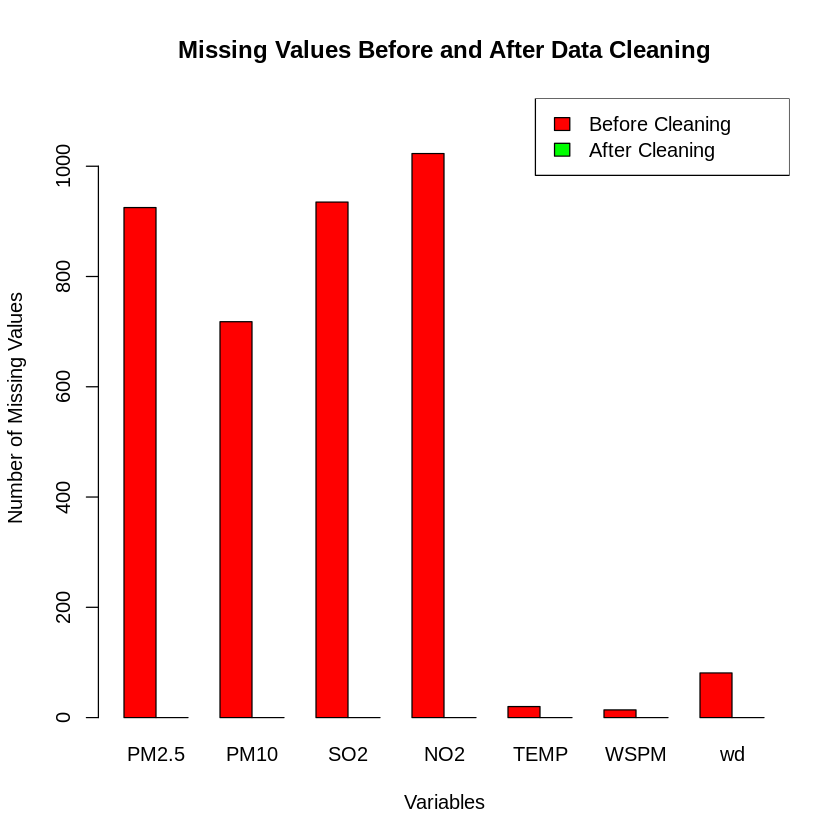

In [12]:
#=========================================================
# Task 9: Visualization
#=========================================================

# Create a matrix for bar plot
missing_matrix <- rbind(
  comparison_table$Missing_Before,
  comparison_table$Missing_After
)

# Draw grouped bar chart
barplot(
  missing_matrix,

  beside = TRUE,

  col = c("red", "green"),

  names.arg = comparison_table$Variable,

  main = "Missing Values Before and After Data Cleaning",

  xlab = "Variables",

  ylab = "Number of Missing Values",

  ylim = c(0, max(comparison_table$Missing_Before) + 100)
)

# Add legend
legend(
  "topright",

  legend = c("Before Cleaning", "After Cleaning"),

  fill = c("red", "green")
)

In [13]:
#=========================================================
# Task 10: Export Cleaned Dataset
#=========================================================

# Export cleaned dataset
write.csv(

  air_data,

  file = "cleaned_air_quality_data.csv",

  row.names = FALSE

)

cat("Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'.\n")

Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'.
